In [1]:
from pathlib import Path
import pandas as pd

data_file = Path("CMAPSSData/train_FD001.txt")
if not data_file.exists():
    data_file = Path("../CMAPSSData/train_FD001.txt")

columns = (
    ["unit_id", "cycle"]
    + [f"setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train = pd.read_csv(data_file, sep=r"\s+", header=None, names=columns)
train = train.sort_values(["unit_id", "cycle"]).reset_index(drop=True)

train["sensor_11_mean_10"] = (
    train.groupby("unit_id")["sensor_11"]
    .transform(lambda values: values.rolling(window=10, min_periods=1).mean())
)

print("Train shape:", train.shape)
print(
    train.loc[
        train["unit_id"] == 1,
        ["cycle", "sensor_11", "sensor_11_mean_10"]
    ].head(12)
)

Train shape: (20631, 27)
    cycle  sensor_11  sensor_11_mean_10
0       1      47.47          47.470000
1       2      47.49          47.480000
2       3      47.27          47.410000
3       4      47.13          47.340000
4       5      47.28          47.328000
5       6      47.16          47.300000
6       7      47.36          47.308571
7       8      47.24          47.300000
8       9      47.29          47.298889
9      10      47.03          47.272000
10     11      47.15          47.240000
11     12      47.18          47.209000


In [2]:
sensor_11_by_engine = train.groupby("unit_id")["sensor_11"]

train["sensor_11_mean_5"] = sensor_11_by_engine.transform(
    lambda values: values.rolling(window=5, min_periods=1).mean()
)

train["sensor_11_mean_20"] = sensor_11_by_engine.transform(
    lambda values: values.rolling(window=20, min_periods=1).mean()
)

train["sensor_11_trend_5_20"] = (
    train["sensor_11_mean_5"] - train["sensor_11_mean_20"]
)

cycles_to_show = [1, 5, 10, 20, 50, 100, 150, 180, 190]
columns_to_show = [
    "cycle", "sensor_11", "sensor_11_mean_5",
    "sensor_11_mean_20", "sensor_11_trend_5_20"
]

print(
    train.loc[
        (train["unit_id"] == 1) &
        (train["cycle"].isin(cycles_to_show)),
        columns_to_show
    ].round(3).to_string(index=False)
)

 cycle  sensor_11  sensor_11_mean_5  sensor_11_mean_20  sensor_11_trend_5_20
     1      47.47            47.470             47.470                 0.000
     5      47.28            47.328             47.328                 0.000
    10      47.03            47.216             47.272                -0.056
    20      47.22            47.238             47.268                -0.030
    50      47.47            47.302             47.314                -0.012
   100      47.64            47.452             47.397                 0.055
   150      47.60            47.670             47.594                 0.076
   180      47.85            47.948             47.896                 0.051
   190      48.33            48.152             48.034                 0.118


In [3]:
sensor_12_by_engine = train.groupby("unit_id")["sensor_12"]

for window in [5, 10, 20]:
    train[f"sensor_12_mean_{window}"] = sensor_12_by_engine.transform(
        lambda values: values.rolling(window=window, min_periods=1).mean()
    )

train["sensor_12_trend_5_20"] = (
    train["sensor_12_mean_5"] - train["sensor_12_mean_20"]
)

columns_to_show = [
    "cycle", "sensor_12", "sensor_12_mean_10",
    "sensor_12_trend_5_20"
]

print(
    train.loc[
        (train["unit_id"] == 1) &
        (train["cycle"].isin([50, 100, 150, 180, 190])),
        columns_to_show
    ].round(3).to_string(index=False)
)

 cycle  sensor_12  sensor_12_mean_10  sensor_12_trend_5_20
    50     522.33            522.054                -0.149
   100     521.55            521.703                -0.023
   150     520.50            520.948                -0.216
   180     519.84            520.156                -0.211
   190     520.04            519.955                -0.251


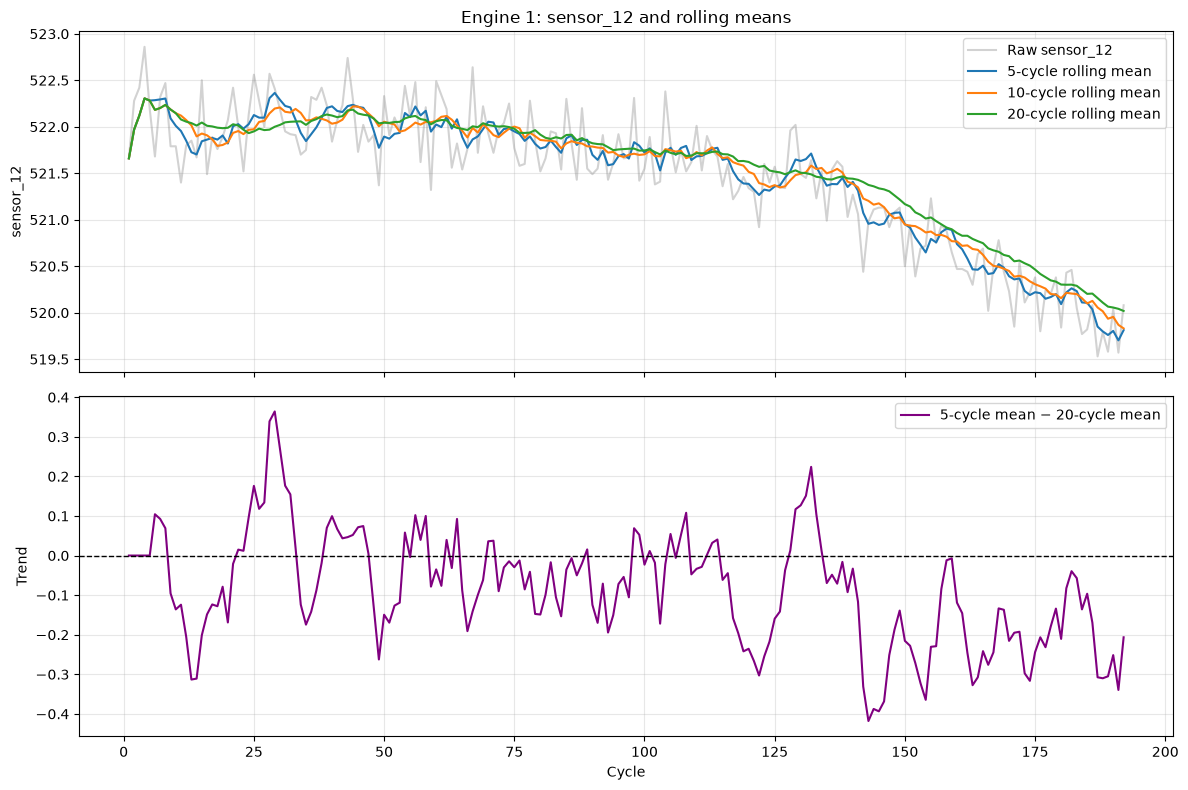

In [4]:
import matplotlib.pyplot as plt

engine_1 = train[train["unit_id"] == 1].sort_values("cycle")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Sensörün anlık değeri ve rolling mean değerleri
axes[0].plot(
    engine_1["cycle"], engine_1["sensor_12"],
    color="gray", alpha=0.35, label="Raw sensor_12"
)
axes[0].plot(
    engine_1["cycle"], engine_1["sensor_12_mean_5"],
    label="5-cycle rolling mean"
)
axes[0].plot(
    engine_1["cycle"], engine_1["sensor_12_mean_10"],
    label="10-cycle rolling mean"
)
axes[0].plot(
    engine_1["cycle"], engine_1["sensor_12_mean_20"],
    label="20-cycle rolling mean"
)
axes[0].set_ylabel("sensor_12")
axes[0].set_title("Engine 1: sensor_12 and rolling means")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Kısa ve uzun dönem ortalamaları arasındaki fark
axes[1].plot(
    engine_1["cycle"], engine_1["sensor_12_trend_5_20"],
    color="purple", label="5-cycle mean − 20-cycle mean"
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Cycle")
axes[1].set_ylabel("Trend")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
RUL_CAP = 125

train["max_cycle"] = train.groupby("unit_id")["cycle"].transform("max")
train["RUL"] = train["max_cycle"] - train["cycle"]
train["RUL_capped"] = train["RUL"].clip(upper=RUL_CAP)

candidate_base_features = (
    ["cycle"]
    + [f"setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

temporal_features = [
    "sensor_11_mean_10",
    "sensor_11_trend_5_20",
    "sensor_12_mean_10",
    "sensor_12_trend_5_20",
]

assert not train[temporal_features].isna().any().any()

print("Engines:", train["unit_id"].nunique())
print("Rows:", len(train))
print("Capped RUL range:",
      train["RUL_capped"].min(), "to", train["RUL_capped"].max())
print("Candidate base features:", len(candidate_base_features))
print("New temporal features:", temporal_features)

print(
    train.loc[
        train["unit_id"] == 1,
        ["cycle", "RUL", "RUL_capped"] + temporal_features
    ].tail(3).round(3)
)

Engines: 100
Rows: 20631
Capped RUL range: 0 to 125
Candidate base features: 25
New temporal features: ['sensor_11_mean_10', 'sensor_11_trend_5_20', 'sensor_12_mean_10', 'sensor_12_trend_5_20']
     cycle  RUL  RUL_capped  sensor_11_mean_10  sensor_11_trend_5_20  \
189    190    2           2             48.109                 0.118   
190    191    1           1             48.114                 0.117   
191    192    0           0             48.141                 0.112   

     sensor_12_mean_10  sensor_12_trend_5_20  
189            519.955                -0.251  
190            519.869                -0.340  
191            519.831                -0.206  


In [6]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupKFold

cv = GroupKFold(n_splits=5)
cv_rows = []
oof_parts = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(train, groups=train["unit_id"]), start=1
):
    train_fold = train.iloc[train_idx]
    val_fold = train.iloc[val_idx]

    assert set(train_fold["unit_id"]).isdisjoint(set(val_fold["unit_id"]))

    # Sabit sütunları yalnızca bu fold'un eğitim verisine göre çıkar
    base_features = [
        col for col in candidate_base_features
        if train_fold[col].nunique() > 1
    ]

    feature_sets = {
        "Baseline": base_features,
        "Baseline + temporal": base_features + temporal_features,
    }

    for feature_set_name, feature_cols in feature_sets.items():
        model = RandomForestRegressor(
            n_estimators=100,
            max_depth=12,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        )

        model.fit(
            train_fold[feature_cols],
            train_fold["RUL_capped"]
        )

        predictions = model.predict(val_fold[feature_cols])
        target = val_fold["RUL_capped"].to_numpy()

        cv_rows.append({
            "fold": fold,
            "feature_set": feature_set_name,
            "features": len(feature_cols),
            "MAE": mean_absolute_error(target, predictions),
            "RMSE": mean_squared_error(target, predictions) ** 0.5,
        })

        oof_parts.append(pd.DataFrame({
            "fold": fold,
            "feature_set": feature_set_name,
            "unit_id": val_fold["unit_id"].to_numpy(),
            "RUL": val_fold["RUL"].to_numpy(),
            "target": target,
            "prediction": predictions,
        }))

    print(f"Fold {fold}/5 completed")

cv_results = pd.DataFrame(cv_rows)
oof_predictions = pd.concat(oof_parts, ignore_index=True)

print("\nResults by fold:")
print(cv_results.round(2).to_string(index=False))

print("\nMean and variation across folds:")
print(
    cv_results.groupby("feature_set")[["MAE", "RMSE"]]
    .agg(["mean", "std"])
    .round(2)
)

Fold 1/5 completed
Fold 2/5 completed
Fold 3/5 completed
Fold 4/5 completed
Fold 5/5 completed

Results by fold:
 fold         feature_set  features   MAE  RMSE
    1            Baseline        18 12.30 17.50
    1 Baseline + temporal        22 11.59 16.69
    2            Baseline        18 11.14 16.48
    2 Baseline + temporal        22 10.65 15.88
    3            Baseline        18 11.91 17.06
    3 Baseline + temporal        22 11.06 16.12
    4            Baseline        18 10.58 15.37
    4 Baseline + temporal        22  9.68 14.68
    5            Baseline        18 11.16 17.03
    5 Baseline + temporal        22 10.84 16.77

Mean and variation across folds:
                       MAE         RMSE      
                      mean   std   mean   std
feature_set                                  
Baseline             11.42  0.68  16.69  0.82
Baseline + temporal  10.76  0.70  16.03  0.84


In [7]:
near_oof = oof_predictions[
    oof_predictions["RUL"].between(0, 50)
].copy()

near_oof["RUL_range"] = pd.cut(
    near_oof["RUL"],
    bins=[-1, 25, 50],
    labels=["0–25", "26–50"]
)

near_oof["signed_error"] = (
    near_oof["prediction"] - near_oof["target"]
)
near_oof["absolute_error"] = near_oof["signed_error"].abs()

near_summary = (
    near_oof.groupby(["feature_set", "RUL_range"], observed=True)
    .agg(
        engines=("unit_id", "nunique"),
        rows=("unit_id", "count"),
        MAE=("absolute_error", "mean"),
        mean_signed_error=("signed_error", "mean"),
        overestimate_pct=(
            "signed_error",
            lambda errors: 100 * (errors > 0).mean()
        ),
    )
    .round(2)
)

print(near_summary)

                               engines  rows    MAE  mean_signed_error  \
feature_set         RUL_range                                            
Baseline            0–25           100  2600   5.79               4.07   
                    26–50          100  2500  14.95              10.37   
Baseline + temporal 0–25           100  2600   4.71               2.66   
                    26–50          100  2500  12.93               8.65   

                               overestimate_pct  
feature_set         RUL_range                    
Baseline            0–25                  74.19  
                    26–50                 66.56  
Baseline + temporal 0–25                  65.35  
                    26–50                 65.88  


In [8]:
cutoff_cycles = [50, 100, 150, 200]

cycle_lookup = train[["unit_id", "RUL", "cycle"]]
assert not cycle_lookup.duplicated(["unit_id", "RUL"]).any()

snapshot_oof = oof_predictions.merge(
    cycle_lookup,
    on=["unit_id", "RUL"],
    how="left",
    validate="many_to_one"
)

assert snapshot_oof["cycle"].notna().all()

snapshot_oof = snapshot_oof[
    snapshot_oof["cycle"].isin(cutoff_cycles)
].copy()

snapshot_oof["signed_error_raw"] = (
    snapshot_oof["prediction"] - snapshot_oof["RUL"]
)
snapshot_oof["absolute_error_raw"] = (
    snapshot_oof["signed_error_raw"].abs()
)

cutoff_summary = (
    snapshot_oof.groupby(["cycle", "feature_set"])
    .agg(
        engines=("unit_id", "nunique"),
        actual_RUL_above_125=("RUL", lambda values: (values > RUL_CAP).sum()),
        MAE_raw=("absolute_error_raw", "mean"),
        mean_signed_error=("signed_error_raw", "mean"),
        overestimate_pct=(
            "signed_error_raw",
            lambda errors: 100 * (errors > 0).mean()
        ),
    )
    .round(2)
)

print(cutoff_summary)

                           engines  actual_RUL_above_125  MAE_raw  \
cycle feature_set                                                   
50    Baseline                 100                    75    43.43   
      Baseline + temporal      100                    75    43.50   
100   Baseline                 100                    26    30.35   
      Baseline + temporal      100                    26    30.31   
150   Baseline                  94                    10    17.72   
      Baseline + temporal       94                    10    17.69   
200   Baseline                  48                     3    11.30   
      Baseline + temporal       48                     3    10.84   

                           mean_signed_error  overestimate_pct  
cycle feature_set                                               
50    Baseline                        -36.48             23.00  
      Baseline + temporal             -36.44             23.00  
100   Baseline                        -12.03     

## Feature engineering — ara sonuç

`Sensor_11` ve `sensor_12` için geçmiş ölçümlerden rolling mean ve kısa dönem trend feature'ları üretildi. Hesaplar her motorun kendi geçmiş ölçümleriyle yapıldı.

Aynı 5-fold GroupKFold bölmelerinde Random Forest karşılaştırması:

| Feature set | Ortalama MAE | Ortalama RMSE |
|---|---:|---:|
| Baseline (18 feature) | 11.42 | 16.69 |
| Baseline + temporal (22 feature) | 10.76 | 16.03 |

Temporal feature'lar 5 fold'un tamamında MAE'yi düşürdü. Gerçek RUL 0–25 aralığında MAE 5.79'dan 4.71'e, 26–50 aralığında 14.95'ten 12.93'e indi. Fazla tahmin oranı 0–25 aralığında %74.19'dan %65.35'e düştü; 26–50 aralığında yaklaşık %66 olarak kaldı.

Sabit cycle'larda motor başına tek tahmin değerlendirmesinde iki modelin MAE değerleri çoğunlukla birbirine yakındı. Erken cycle'larda birçok motorun gerçek RUL'si 125'in üzerinde olduğundan, capped hedefle eğitilen modellerin uncapped RUL hatası yüksekti. Ayrıca sonraki cutoff'lara yalnızca o cycle'a ulaşmış motorlar dahildi.

Sonraki değerlendirme için `Baseline + temporal` modeli, test sonucuna göre değil train verisindeki GroupKFold sonuçlarına göre seçildi.

In [9]:
test_file = data_file.with_name("test_FD001.txt")

test = pd.read_csv(
    test_file,
    sep=r"\s+",
    header=None,
    names=columns
)
test = test.sort_values(["unit_id", "cycle"]).reset_index(drop=True)

for sensor in ["sensor_11", "sensor_12"]:
    values_by_engine = test.groupby("unit_id")[sensor]

    for window in [5, 10, 20]:
        test[f"{sensor}_mean_{window}"] = values_by_engine.transform(
            lambda values: values.rolling(
                window=window, min_periods=1
            ).mean()
        )

    test[f"{sensor}_trend_5_20"] = (
        test[f"{sensor}_mean_5"] - test[f"{sensor}_mean_20"]
    )

# Her test motorunun son gözlemi
test_last = (
    test.groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

assert len(test_last) == 100
assert not test[temporal_features].isna().any().any()

print("Test shape:", test.shape)
print("Test engines:", test["unit_id"].nunique())
print("Last-observation rows:", len(test_last))
print("Missing temporal values:", test[temporal_features].isna().sum().sum())

print(
    test_last[["unit_id", "cycle"] + temporal_features]
    .head()
    .round(3)
)

Test shape: (13096, 34)
Test engines: 100
Last-observation rows: 100
Missing temporal values: 0
   unit_id  cycle  sensor_11_mean_10  sensor_11_trend_5_20  sensor_12_mean_10  \
0        1     31             47.288                -0.025            521.930   
1        2     49             47.509                 0.015            521.514   
2        3    126             47.705                 0.032            520.795   
3        4    106             47.630                 0.056            521.324   
4        5     98             47.533                -0.019            521.115   

   sensor_12_trend_5_20  
0                -0.066  
1                 0.029  
2                -0.258  
3                 0.068  
4                -0.214  


In [10]:
full_base_features = [
    col for col in candidate_base_features
    if train[col].nunique() > 1
]
final_feature_cols = full_base_features + temporal_features

assert len(final_feature_cols) == 22
assert test_last["unit_id"].tolist() == list(range(1, 101))

final_temporal_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)

final_temporal_model.fit(
    train[final_feature_cols],
    train["RUL_capped"]
)

test_predictions_temporal = test_last[["unit_id", "cycle"]].copy()
test_predictions_temporal = test_predictions_temporal.rename(
    columns={"cycle": "last_observed_cycle"}
)
test_predictions_temporal["predicted_RUL_capped"] = (
    final_temporal_model.predict(test_last[final_feature_cols])
)

print("Model features:", len(final_feature_cols))
print("Prediction count:", len(test_predictions_temporal))
print(
    "Prediction range:",
    round(test_predictions_temporal["predicted_RUL_capped"].min(), 2),
    "to",
    round(test_predictions_temporal["predicted_RUL_capped"].max(), 2)
)
print(test_predictions_temporal.head().round(2))

Model features: 22
Prediction count: 100
Prediction range: 6.55 to 123.8
   unit_id  last_observed_cycle  predicted_RUL_capped
0        1                   31                123.60
1        2                   49                121.04
2        3                  126                 49.31
3        4                  106                 86.57
4        5                   98                 91.24


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_rul_file = test_file.with_name("RUL_FD001.txt")
test_rul = pd.read_csv(test_rul_file, sep=r"\s+", header=None)

assert len(test_rul) == len(test_predictions_temporal) == 100

temporal_results = test_predictions_temporal.copy()
temporal_results["true_RUL"] = test_rul.iloc[:, 0].to_numpy()
temporal_results["true_RUL_capped"] = (
    temporal_results["true_RUL"].clip(upper=RUL_CAP)
)

prediction = temporal_results["predicted_RUL_capped"]

for name, target in [
    ("Actual test RUL", temporal_results["true_RUL"]),
    ("Capped test RUL", temporal_results["true_RUL_capped"]),
]:
    print(name)
    print("MAE: ", round(mean_absolute_error(target, prediction), 2))
    print("RMSE:", round(mean_squared_error(target, prediction) ** 0.5, 2))
    print("R²:  ", round(r2_score(target, prediction), 3))
    print()

print("Actual RUL above 125:",
      (temporal_results["true_RUL"] > RUL_CAP).sum())

temporal_results["signed_error"] = (
    temporal_results["predicted_RUL_capped"]
    - temporal_results["true_RUL"]
)
print(temporal_results.head().round(2))

Actual test RUL
MAE:  13.39
RMSE: 18.05
R²:   0.811

Capped test RUL
MAE:  12.32
RMSE: 16.79
R²:   0.825

Actual RUL above 125: 11
   unit_id  last_observed_cycle  predicted_RUL_capped  true_RUL  \
0        1                   31                123.60       112   
1        2                   49                121.04        98   
2        3                  126                 49.31        69   
3        4                  106                 86.57        82   
4        5                   98                 91.24        91   

   true_RUL_capped  signed_error  
0              112         11.60  
1               98         23.04  
2               69        -19.69  
3               82          4.57  
4               91          0.24  


In [12]:
baseline_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)

baseline_model.fit(
    train[full_base_features],
    train["RUL_capped"]
)

assert (
    test_last["unit_id"].to_numpy()
    == temporal_results["unit_id"].to_numpy()
).all()

comparison = temporal_results[["unit_id", "true_RUL"]].copy()
comparison["Baseline"] = baseline_model.predict(
    test_last[full_base_features]
)
comparison["Temporal"] = temporal_results["predicted_RUL_capped"]

print(
    "Baseline test MAE check:",
    round(mean_absolute_error(
        comparison["true_RUL"], comparison["Baseline"]
    ), 2)
)

near_comparison = comparison.melt(
    id_vars=["unit_id", "true_RUL"],
    value_vars=["Baseline", "Temporal"],
    var_name="model",
    value_name="prediction"
)

near_comparison = near_comparison[
    near_comparison["true_RUL"].between(0, 50)
].copy()

near_comparison["RUL_range"] = pd.cut(
    near_comparison["true_RUL"],
    bins=[-1, 25, 50],
    labels=["0–25", "26–50"]
)

near_comparison["signed_error"] = (
    near_comparison["prediction"] - near_comparison["true_RUL"]
)
near_comparison["absolute_error"] = (
    near_comparison["signed_error"].abs()
)

test_near_summary = (
    near_comparison.groupby(["model", "RUL_range"], observed=True)
    .agg(
        engines=("unit_id", "count"),
        MAE=("absolute_error", "mean"),
        mean_signed_error=("signed_error", "mean"),
        overestimate_pct=(
            "signed_error",
            lambda errors: 100 * (errors > 0).mean()
        ),
    )
    .round(2)
)

print(test_near_summary)

Baseline test MAE check: 13.51
                    engines    MAE  mean_signed_error  overestimate_pct
model    RUL_range                                                     
Baseline 0–25            19   8.77               7.48             68.42
         26–50           14   7.88               5.99             78.57
Temporal 0–25            19   7.70               7.14             73.68
         26–50           14  10.12               5.13             78.57


## Final evaluation — temporal features

`Sensor_11` ve `sensor_12` için geçmiş ölçümlerden dört temporal feature üretildi. Her feature yalnızca ilgili motorun mevcut ve önceki cycle ölçümlerini kullanır.

### Train validation

5-fold GroupKFold değerlendirmesinde temporal modelin ortalama MAE değeri 11.42'den 10.76'ya, RMSE değeri 16.69'dan 16.03'e düştü. Temporal model 5 fold'un tamamında daha düşük MAE elde etti. Arızaya yakın out-of-fold gözlemlerde de MAE azaldı.

### Test: motor başına son gözlem

Gerçek, uncapped RUL üzerinden baseline ve temporal model sonuçları:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Baseline | 13.51 | 18.02 | 0.812 |
| Baseline + temporal | 13.39 | 18.05 | 0.811 |

Test MAE farkı yalnızca 0.12 cycle; RMSE ve R² için iyileşme yok. Gerçek RUL'si 125'in üzerinde olan 11 motor bulunuyor; capped hedef bu motorlarda tahmin aralığını sınırlandırıyor.

Arızaya yakın test motorlarında sonuçlar karışık: RUL 0–25 grubunda MAE 8.77'den 7.70'e indi, ancak fazla tahmin edilen motor sayısı 13/19'dan 14/19'a çıktı. RUL 26–50 grubunda MAE 7.88'den 10.12'ye yükseldi; iki model de 11/14 motorun kalan ömrünü fazla tahmin etti.

### Sonuç

Temporal feature'lar train verisindeki GroupKFold performansını iyileştirdi. Test motorlarının son gözleminde ise belirgin bir genel iyileşme veya arızaya yakın motorlar için daha düşük bakım riski göstermedi. Test sonuçları model geliştirmek için tekrar tekrar kullanılmamalı; sonraki model kararları train verisindeki validation sonuçlarına dayanmalı.

In [13]:
ALERT_THRESHOLD = 25

alert_eval = oof_predictions.copy()
alert_eval["true_alert"] = alert_eval["RUL"] <= ALERT_THRESHOLD
alert_eval["predicted_alert"] = (
    alert_eval["prediction"] <= ALERT_THRESHOLD
)

alert_rows = []

for model_name, group in alert_eval.groupby("feature_set"):
    true_alert = group["true_alert"]
    predicted_alert = group["predicted_alert"]

    tp = (true_alert & predicted_alert).sum()
    fn = (true_alert & ~predicted_alert).sum()
    fp = (~true_alert & predicted_alert).sum()
    tn = (~true_alert & ~predicted_alert).sum()

    alert_rows.append({
        "model": model_name,
        "correct_alerts_TP": tp,
        "missed_alerts_FN": fn,
        "early_alerts_FP": fp,
        "correct_no_alert_TN": tn,
        "precision_pct": 100 * tp / (tp + fp),
        "recall_pct": 100 * tp / (tp + fn),
    })

alert_summary = pd.DataFrame(alert_rows).round(2)
print(alert_summary.to_string(index=False))

              model  correct_alerts_TP  missed_alerts_FN  early_alerts_FP  correct_no_alert_TN  precision_pct  recall_pct
           Baseline               2097               503              204                17827          91.13       80.65
Baseline + temporal               2168               432              184                17847          92.18       83.38


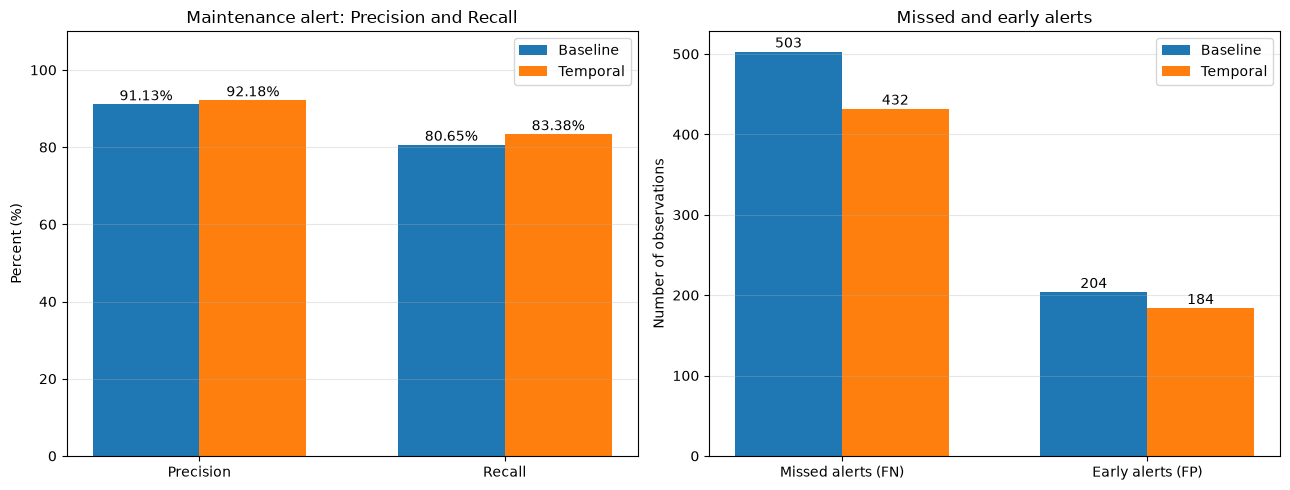

In [14]:
import numpy as np
import matplotlib.pyplot as plt

plot_data = alert_summary.set_index("model").loc[
    ["Baseline", "Baseline + temporal"]
]

labels = ["Precision", "Recall"]
baseline_rates = plot_data.loc[
    "Baseline", ["precision_pct", "recall_pct"]
].to_numpy()
temporal_rates = plot_data.loc[
    "Baseline + temporal", ["precision_pct", "recall_pct"]
].to_numpy()

error_labels = ["Missed alerts (FN)", "Early alerts (FP)"]
baseline_errors = plot_data.loc[
    "Baseline", ["missed_alerts_FN", "early_alerts_FP"]
].to_numpy()
temporal_errors = plot_data.loc[
    "Baseline + temporal", ["missed_alerts_FN", "early_alerts_FP"]
].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
width = 0.35
x = np.arange(2)

bars_base = axes[0].bar(
    x - width / 2, baseline_rates, width, label="Baseline"
)
bars_temp = axes[0].bar(
    x + width / 2, temporal_rates, width, label="Temporal"
)
axes[0].set_xticks(x, labels)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel("Percent (%)")
axes[0].set_title("Maintenance alert: Precision and Recall")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for bars in [bars_base, bars_temp]:
    for bar in bars:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{bar.get_height():.2f}%",
            ha="center"
        )

bars_base = axes[1].bar(
    x - width / 2, baseline_errors, width, label="Baseline"
)
bars_temp = axes[1].bar(
    x + width / 2, temporal_errors, width, label="Temporal"
)
axes[1].set_xticks(x, error_labels)
axes[1].set_ylabel("Number of observations")
axes[1].set_title("Missed and early alerts")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

for bars in [bars_base, bars_temp]:
    for bar in bars:
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"{bar.get_height():.0f}",
            ha="center"
        )

plt.tight_layout()
plt.show()

In [15]:
# Her model ve motor için bütün gözlemleri koru
all_engines = alert_eval[["feature_set", "unit_id"]].drop_duplicates()

# İlk uyarı, zaman açısından en erken; yani RUL değeri en yüksek uyarı
first_alert = (
    alert_eval[alert_eval["predicted_alert"]]
    .groupby(["feature_set", "unit_id"], as_index=False)["RUL"]
    .max()
    .rename(columns={"RUL": "first_alert_RUL"})
)

engine_alerts = all_engines.merge(
    first_alert,
    on=["feature_set", "unit_id"],
    how="left",
    validate="one_to_one"
)

engine_summary = (
    engine_alerts.groupby("feature_set")
    .agg(
        engines=("unit_id", "count"),
        never_alerted=("first_alert_RUL", lambda values: values.isna().sum()),
        first_alert_at_least_25_cycles_before_failure=(
            "first_alert_RUL",
            lambda values: (values >= 25).sum()
        ),
        first_alert_with_less_than_25_cycles_left=(
            "first_alert_RUL",
            lambda values: (values < 25).sum()
        ),
        median_first_alert_RUL=("first_alert_RUL", "median"),
    )
    .round(1)
)

print(engine_summary)

print("\nFirst 10 engines:")
print(
    engine_alerts.pivot(
        index="unit_id",
        columns="feature_set",
        values="first_alert_RUL"
    ).head(10)
)

                     engines  never_alerted  \
feature_set                                   
Baseline                 100              0   
Baseline + temporal      100              0   

                     first_alert_at_least_25_cycles_before_failure  \
feature_set                                                          
Baseline                                                        49   
Baseline + temporal                                             48   

                     first_alert_with_less_than_25_cycles_left  \
feature_set                                                      
Baseline                                                    51   
Baseline + temporal                                         52   

                     median_first_alert_RUL  
feature_set                                  
Baseline                               24.0  
Baseline + temporal                    24.0  

First 10 engines:
feature_set  Baseline  Baseline + temporal
unit_id            

In [16]:
stable_eval = alert_eval.sort_values(
    ["feature_set", "unit_id", "RUL"],
    ascending=[True, True, False]
).copy()

# Ardışık satırların gerçekten ardışık cycle olduğunu kontrol et
assert (
    stable_eval.groupby(["feature_set", "unit_id"])["RUL"]
    .diff()
    .dropna()
    .eq(-1)
    .all()
)

stable_eval["confirmed_alert"] = (
    stable_eval.groupby(["feature_set", "unit_id"])["predicted_alert"]
    .transform(
        lambda alerts: alerts.rolling(window=3, min_periods=3)
        .sum()
        .eq(3)
    )
)

first_confirmed = (
    stable_eval[stable_eval["confirmed_alert"]]
    .groupby(["feature_set", "unit_id"], as_index=False)["RUL"]
    .max()
    .rename(columns={"RUL": "first_confirmed_alert_RUL"})
)

confirmed_engine_alerts = all_engines.merge(
    first_confirmed,
    on=["feature_set", "unit_id"],
    how="left",
    validate="one_to_one"
)

confirmed_summary = (
    confirmed_engine_alerts.groupby("feature_set")
    .agg(
        engines=("unit_id", "count"),
        never_confirmed=(
            "first_confirmed_alert_RUL",
            lambda values: values.isna().sum()
        ),
        confirmed_at_least_25_cycles_before_failure=(
            "first_confirmed_alert_RUL",
            lambda values: (values >= 25).sum()
        ),
        confirmed_with_less_than_25_cycles_left=(
            "first_confirmed_alert_RUL",
            lambda values: (values < 25).sum()
        ),
        median_confirmed_alert_RUL=(
            "first_confirmed_alert_RUL", "median"
        ),
    )
    .round(1)
)

print(confirmed_summary)

                     engines  never_confirmed  \
feature_set                                     
Baseline                 100                0   
Baseline + temporal      100                0   

                     confirmed_at_least_25_cycles_before_failure  \
feature_set                                                        
Baseline                                                      23   
Baseline + temporal                                           28   

                     confirmed_with_less_than_25_cycles_left  \
feature_set                                                    
Baseline                                                  77   
Baseline + temporal                                       72   

                     median_confirmed_alert_RUL  
feature_set                                      
Baseline                                   18.0  
Baseline + temporal                        19.0  


In [17]:
MIN_LEAD_TIME = 20

lead_time_summary = (
    confirmed_engine_alerts.groupby("feature_set")
    .agg(
        engines=("unit_id", "count"),
        confirmed_with_20_or_more_cycles_left=(
            "first_confirmed_alert_RUL",
            lambda values: (values >= MIN_LEAD_TIME).sum()
        ),
        confirmed_with_less_than_20_cycles_left=(
            "first_confirmed_alert_RUL",
            lambda values: (values < MIN_LEAD_TIME).sum()
        ),
        never_confirmed=(
            "first_confirmed_alert_RUL",
            lambda values: values.isna().sum()
        ),
        median_lead_time=("first_confirmed_alert_RUL", "median"),
    )
    .round(1)
)

print(lead_time_summary)

                     engines  confirmed_with_20_or_more_cycles_left  \
feature_set                                                           
Baseline                 100                                     43   
Baseline + temporal      100                                     49   

                     confirmed_with_less_than_20_cycles_left  never_confirmed  \
feature_set                                                                     
Baseline                                                  57                0   
Baseline + temporal                                       51                0   

                     median_lead_time  
feature_set                            
Baseline                         18.0  
Baseline + temporal              19.0  


In [18]:
sweep_data = oof_predictions.sort_values(
    ["feature_set", "unit_id", "RUL"],
    ascending=[True, True, False]
).copy()

engine_keys = sweep_data[["feature_set", "unit_id"]].drop_duplicates()
sweep_rows = []

for threshold in [20, 25, 30, 35, 40]:
    sweep_data["predicted_alert"] = (
        sweep_data["prediction"] <= threshold
    )

    sweep_data["confirmed_alert"] = (
        sweep_data.groupby(["feature_set", "unit_id"])["predicted_alert"]
        .transform(
            lambda alerts: alerts.rolling(window=3, min_periods=3)
            .sum()
            .eq(3)
        )
    )

    first_confirmed = (
        sweep_data[sweep_data["confirmed_alert"]]
        .groupby(["feature_set", "unit_id"], as_index=False)["RUL"]
        .max()
        .rename(columns={"RUL": "first_confirmed_RUL"})
    )

    engine_results = engine_keys.merge(
        first_confirmed,
        on=["feature_set", "unit_id"],
        how="left",
        validate="one_to_one"
    )

    for model_name, group in engine_results.groupby("feature_set"):
        lead = group["first_confirmed_RUL"]

        sweep_rows.append({
            "threshold": threshold,
            "model": model_name,
            "engines_with_20plus_lead": (lead >= 20).sum(),
            "engines_with_under_20_lead": (lead < 20).sum(),
            "never_confirmed": lead.isna().sum(),
            "confirmed_over_50_cycles_early": (lead > 50).sum(),
            "median_lead": lead.median(),
        })

threshold_summary = pd.DataFrame(sweep_rows)
print(threshold_summary.to_string(index=False))

 threshold               model  engines_with_20plus_lead  engines_with_under_20_lead  never_confirmed  confirmed_over_50_cycles_early  median_lead
        20            Baseline                        17                          83                0                               0         14.0
        20 Baseline + temporal                        27                          73                0                               0         16.0
        25            Baseline                        43                          57                0                               0         18.0
        25 Baseline + temporal                        49                          51                0                               0         19.0
        30            Baseline                        62                          38                0                               0         24.0
        30 Baseline + temporal                        69                          31                0                 

## Exploratory maintenance alert evaluation

RUL tahminlerinden örnek bir bakım uyarısı üretmek için tahmini RUL ≤25 eşiği denendi. Değerlendirme, train motorlarının out-of-fold tahminleriyle yapıldı.

Cycle düzeyinde temporal modelin Recall değeri %80.65'ten %83.38'e, Precision değeri %91.13'ten %92.18'e yükseldi. Kaçırılan yakın-arızalı gözlem sayısı 503'ten 432'ye düştü. Bu sayılar motor değil, aynı motorların farklı cycle gözlemleridir.

Motor başına tek uyarıda ilk uyarının median zamanı iki modelde de arızaya 24 cycle kalaydı. Üç ardışık uyarı şartında median onay zamanı baseline için 18, temporal model için 19 cycle kalaydı.

Örnek 20-cycle lead-time hedefinde, üç ardışık uyarı kuralıyla baseline 43/100, temporal model 49/100 motoru yeterince erken uyardı. Temporal modelin sonucu daha iyi olsa da 51 motorun uyarısı 20 cycle'dan az süre kala onaylandı.

Tahmini RUL uyarı eşiği 25'ten 30'a yükseltildiğinde temporal modelin en az 20 cycle kala uyardığı motor sayısı 49'dan 69'a çıktı. Eşik 35'te bu sayı 81'e yükseldi; arızaya 50 cycle'dan fazla varken onaylanan motor sayısı da 5 oldu.

Bu eşikler gerçek bakım gereksinimi değil, örnek senaryolardır. Lead-time ihtiyacı ve erken bakım maliyeti bilinmeden en iyi eşik seçilemez. Aynı out-of-fold sonuçları üzerinde eşik seçip başarıyı yine bu sonuçlarla raporlamak iyimser olabilir; seçilen kural ayrıca doğrulanmalıdır.

In [19]:
TEST_ALERT_THRESHOLD = 30

test_alerts = test[["unit_id", "cycle"]].copy()
test_alerts["predicted_RUL"] = final_temporal_model.predict(
    test[final_feature_cols]
)

test_alerts["below_threshold"] = (
    test_alerts["predicted_RUL"] <= TEST_ALERT_THRESHOLD
)

# Uyarı, aynı motorda 3 ardışık cycle koşul sağlandığında onaylanır
test_alerts["confirmed_now"] = (
    test_alerts.groupby("unit_id")["below_threshold"]
    .transform(
        lambda alerts: alerts.rolling(window=3, min_periods=3)
        .sum()
        .eq(3)
    )
)

# Bir kez onaylandıysa, motor "uyarı aldı" olarak kaydedilir
test_alerts["ever_confirmed"] = (
    test_alerts.groupby("unit_id")["confirmed_now"].cummax()
)

last_test_alert = (
    test_alerts.groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

print("Test engines:", len(last_test_alert))
print("Confirmed alert at last cycle:",
      last_test_alert["confirmed_now"].sum())
print("Alert confirmed at least once:",
      last_test_alert["ever_confirmed"].sum())

print("\nFirst engines with a confirmed alert:")
print(
    last_test_alert[last_test_alert["ever_confirmed"]]
    .head(5)
    .round(2)
)

Test engines: 100
Confirmed alert at last cycle: 18
Alert confirmed at least once: 18

First engines with a confirmed alert:
    unit_id  cycle  predicted_RUL  below_threshold  confirmed_now  \
19       20    184          20.79             True           True   
23       24    186          21.96             True           True   
30       31    196          13.15             True           True   
33       34    203           6.55             True           True   
34       35    198          10.69             True           True   

    ever_confirmed  
19            True  
23            True  
30            True  
33            True  
34            True  


In [20]:
URGENT_RUL = 20

test_alert_eval = last_test_alert.merge(
    temporal_results[
        ["unit_id", "last_observed_cycle", "true_RUL"]
    ],
    on="unit_id",
    how="left",
    validate="one_to_one"
)

assert (
    test_alert_eval["cycle"]
    == test_alert_eval["last_observed_cycle"]
).all()

test_alert_eval["actually_urgent"] = (
    test_alert_eval["true_RUL"] <= URGENT_RUL
)

tp = (
    test_alert_eval["ever_confirmed"]
    & test_alert_eval["actually_urgent"]
).sum()

fn = (
    ~test_alert_eval["ever_confirmed"]
    & test_alert_eval["actually_urgent"]
).sum()

fp = (
    test_alert_eval["ever_confirmed"]
    & ~test_alert_eval["actually_urgent"]
).sum()

tn = (
    ~test_alert_eval["ever_confirmed"]
    & ~test_alert_eval["actually_urgent"]
).sum()

print("Truly within 20 cycles of failure:", tp + fn)
print("Alert confirmed by last observation:", tp + fp)
print("Alert + true RUL <= 20 (TP):", tp)
print("No alert + true RUL <= 20 (FN):", fn)
print("Alert + true RUL > 20 (early alert):", fp)
print("No alert + true RUL > 20 (TN):", tn)

print("\nFirst 10 alerted engines:")
print(
    test_alert_eval.loc[
        test_alert_eval["ever_confirmed"],
        ["unit_id", "cycle", "predicted_RUL", "true_RUL"]
    ]
    .sort_values("true_RUL")
    .head(10)
    .round(2)
    .to_string(index=False)
)

Truly within 20 cycles of failure: 16
Alert confirmed by last observation: 18
Alert + true RUL <= 20 (TP): 15
No alert + true RUL <= 20 (FN): 1
Alert + true RUL > 20 (early alert): 3
No alert + true RUL > 20 (TN): 81

First 10 alerted engines:
 unit_id  cycle  predicted_RUL  true_RUL
      34    203           6.55         7
      31    196          13.15         8
      81    213           9.93         8
      68    187          13.05         8
      82    162           9.12         9
      42    156          15.93        10
      76    205          12.02        10
      35    198          10.69        11
      66    147          16.21        14
      56    136          14.14        15


In [21]:
first_confirmed_test = (
    test_alerts[test_alerts["confirmed_now"]]
    .groupby("unit_id", as_index=False)["cycle"]
    .min()
    .rename(columns={"cycle": "first_confirmed_cycle"})
)

test_alert_timing = temporal_results[
    ["unit_id", "last_observed_cycle", "true_RUL"]
].merge(
    first_confirmed_test,
    on="unit_id",
    how="left",
    validate="one_to_one"
)

test_alert_timing["inferred_failure_cycle"] = (
    test_alert_timing["last_observed_cycle"]
    + test_alert_timing["true_RUL"]
)

test_alert_timing["lead_cycles_at_first_alert"] = (
    test_alert_timing["inferred_failure_cycle"]
    - test_alert_timing["first_confirmed_cycle"]
)

observed_alerts = test_alert_timing.dropna(
    subset=["first_confirmed_cycle"]
).copy()

assert len(observed_alerts) == last_test_alert["ever_confirmed"].sum()

print("Engines with an observed confirmed alert:", len(observed_alerts))
print(
    "Alert at least 20 cycles before failure:",
    (observed_alerts["lead_cycles_at_first_alert"] >= 20).sum()
)
print(
    "Alert fewer than 20 cycles before failure:",
    (observed_alerts["lead_cycles_at_first_alert"] < 20).sum()
)
print(
    "Median lead time:",
    observed_alerts["lead_cycles_at_first_alert"].median()
)
print(
    "Engines without an alert before test cutoff:",
    test_alert_timing["first_confirmed_cycle"].isna().sum()
)

print("\nObserved alerts, shortest lead time first:")
print(
    observed_alerts[
        ["unit_id", "first_confirmed_cycle",
         "last_observed_cycle", "true_RUL",
         "lead_cycles_at_first_alert"]
    ]
    .sort_values("lead_cycles_at_first_alert")
    .to_string(index=False)
)

Engines with an observed confirmed alert: 18
Alert at least 20 cycles before failure: 16
Alert fewer than 20 cycles before failure: 2
Median lead time: 25.5
Engines without an alert before test cutoff: 82

Observed alerts, shortest lead time first:
 unit_id  first_confirmed_cycle  last_observed_cycle  true_RUL  lead_cycles_at_first_alert
      82                  158.0                  162         9                        13.0
      42                  153.0                  156        10                        13.0
      20                  180.0                  184        16                        20.0
      34                  190.0                  203         7                        20.0
      92                  150.0                  150        20                        20.0
      68                  175.0                  187         8                        20.0
      31                  181.0                  196         8                        23.0
      24               

In [22]:
baseline_test_alerts = test[["unit_id", "cycle"]].copy()

baseline_test_alerts["predicted_RUL"] = baseline_model.predict(
    test[full_base_features]
)

baseline_test_alerts["below_threshold"] = (
    baseline_test_alerts["predicted_RUL"] <= TEST_ALERT_THRESHOLD
)

baseline_test_alerts["confirmed_now"] = (
    baseline_test_alerts.groupby("unit_id")["below_threshold"]
    .transform(
        lambda alerts: alerts.rolling(window=3, min_periods=3)
        .sum()
        .eq(3)
    )
)

baseline_test_alerts["ever_confirmed"] = (
    baseline_test_alerts.groupby("unit_id")["confirmed_now"].cummax()
)

baseline_last_alert = (
    baseline_test_alerts.groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

print("Baseline test engines:", len(baseline_last_alert))
print(
    "Baseline motors alerted by last observation:",
    baseline_last_alert["ever_confirmed"].sum()
)
print(
    "Temporal motors alerted by last observation:",
    last_test_alert["ever_confirmed"].sum()
)

print("\nFirst baseline-alerted motors:")
print(
    baseline_last_alert[baseline_last_alert["ever_confirmed"]]
    .head(5)
    .round(2)
)

Baseline test engines: 100
Baseline motors alerted by last observation: 17
Temporal motors alerted by last observation: 18

First baseline-alerted motors:
    unit_id  cycle  predicted_RUL  below_threshold  confirmed_now  \
19       20    184          23.17             True           True   
23       24    186          20.61             True           True   
30       31    196          21.30             True           True   
33       34    203           7.01             True           True   
34       35    198           7.46             True           True   

    ever_confirmed  
19            True  
23            True  
30            True  
33            True  
34            True  


In [23]:
baseline_first_confirmed = (
    baseline_test_alerts[baseline_test_alerts["confirmed_now"]]
    .groupby("unit_id", as_index=False)["cycle"]
    .min()
    .rename(columns={"cycle": "first_confirmed_cycle"})
)

baseline_alert_timing = temporal_results[
    ["unit_id", "last_observed_cycle", "true_RUL"]
].merge(
    baseline_first_confirmed,
    on="unit_id",
    how="left",
    validate="one_to_one"
)

baseline_alert_timing["inferred_failure_cycle"] = (
    baseline_alert_timing["last_observed_cycle"]
    + baseline_alert_timing["true_RUL"]
)
baseline_alert_timing["lead_cycles_at_first_alert"] = (
    baseline_alert_timing["inferred_failure_cycle"]
    - baseline_alert_timing["first_confirmed_cycle"]
)

comparison_rows = []

for model_name, result in [
    ("Baseline", baseline_alert_timing),
    ("Temporal", test_alert_timing),
]:
    alerted = result["first_confirmed_cycle"].notna()
    urgent = result["true_RUL"] <= 20
    timely = result["lead_cycles_at_first_alert"] >= 20

    comparison_rows.append({
        "model": model_name,
        "alerted_motors": alerted.sum(),
        "urgent_motors_alerted": (urgent & alerted).sum(),
        "urgent_motors_missed": (urgent & ~alerted).sum(),
        "urgent_motors_with_20plus_lead": (urgent & timely).sum(),
        "all_alerts_with_20plus_lead": timely.sum(),
        "median_lead_among_alerted": (
            result["lead_cycles_at_first_alert"].median()
        ),
    })

alert_model_comparison = pd.DataFrame(comparison_rows).round(1)
print(alert_model_comparison.to_string(index=False))

flag_difference = baseline_last_alert[
    ["unit_id", "ever_confirmed"]
].merge(
    last_test_alert[["unit_id", "ever_confirmed"]],
    on="unit_id",
    suffixes=("_baseline", "_temporal")
)

print("\nMotors with different alert decisions:")
print(
    flag_difference.loc[
        flag_difference["ever_confirmed_baseline"]
        != flag_difference["ever_confirmed_temporal"]
    ].to_string(index=False)
)

   model  alerted_motors  urgent_motors_alerted  urgent_motors_missed  urgent_motors_with_20plus_lead  all_alerts_with_20plus_lead  median_lead_among_alerted
Baseline              17                     15                     1                              11                           13                       23.0
Temporal              18                     15                     1                              13                           16                       25.5

Motors with different alert decisions:
 unit_id  ever_confirmed_baseline  ever_confirmed_temporal
      90                    False                     True


## Test motorlarında bakım uyarısı — keşifsel sonuç

Train out-of-fold analizinde denenen örnek kural test motorlarının gözlemlenmiş geçmişine uygulandı: tahmini RUL ≤30 koşulu aynı motorda 3 cycle üst üste gerçekleşirse uyarı onaylandı. Eşik, test sonucuna göre değiştirilmedi.

| Sonuç | Baseline | Baseline + temporal |
|---|---:|---:|
| Son gözleme kadar uyarı alan motor | 17 | 18 |
| Gerçek RUL ≤20 olup uyarılan motor | 15 | 15 |
| Gerçek RUL ≤20 olup uyarılmayan motor | 1 | 1 |
| Gerçek RUL ≤20 olup en az 20 cycle kala uyarılan motor | 11 | 13 |
| Tüm gözlenen uyarılardan en az 20 cycle kala verilen | 13 | 16 |
| Uyarı alan motorlarda median lead time | 23 | 25.5 cycle |

İki model de son gözlemde arızaya 20 cycle veya daha az kalan 16 motorun 15'ini uyardı. Temporal model, bu motorların ikisini daha en az 20 cycle kala uyardı. Uyarı kararı farklı olan tek motor 90'dı: yalnızca temporal model uyarı verdi; son gözlemde gerçek RUL 28 idi.

Test verisi arızadan önce kesildiği için, kesim anına kadar uyarı almayan motorların sonraki cycle'lardaki davranışı bilinmiyor. İlk uyarı lead time değerleri yalnızca gözlemlenmiş uyarılar için hesaplandı. Bu eşikler örnek bakım senaryosudur; gerçek bakım süresi ve maliyetleri tanımlanmadan operasyonel kural olarak seçilemez. Test daha önce RUL değerlendirmesinde de incelendiği için bu karşılaştırma keşifsel olarak yorumlanmalıdır.